In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.express as px
from kaggle.api.kaggle_api_extended import KaggleApi
from src.utils.geo import US_STATES_MAPPING
from src.features.build_features import engineer_fraud_features
!pip install folium


CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == 'notebooks' else CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_PATH = PROJECT_ROOT / 'data' / 'processed'

print(f"✅ Ambiente configurado. Raiz do projeto: {PROJECT_ROOT}")

✅ Ambiente configurado. Raiz do projeto: c:\Users\Jp Lima\Desktop\fraud_detection


In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

DATA_RAW_DIR = os.path.join('..', 'data', 'raw')
DATA_PROCESSED_DIR = os.path.join('..', 'data', 'processed')

train_path = os.path.join(DATA_RAW_DIR, 'fraudTrain.csv')
test_path = os.path.join(DATA_RAW_DIR, 'fraudTest.csv')

print("⏳ Carregando bases de dados...")
df_train = pd.read_csv(train_path, index_col=0)
df_test = pd.read_csv(test_path, index_col=0)

df = pd.concat([df_train, df_test], ignore_index=True)
print(f"📊 Dataset unificado carregado! Total de registros: {df.shape[0]:,}")

⏳ Carregando bases de dados...
📊 Dataset unificado carregado! Total de registros: 1,852,394


In [31]:
# Configuração de estilo padrão para manter a consistência visual
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11, 
    'axes.labelsize': 12, 
    'axes.titlesize': 14,
    'figure.titlesize': 16
})

In [ ]:
print("\n--- Executando Sanity Check ---")
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

missing_data = df.isnull().sum()
if missing_data.sum() == 0:
    print("✅ Nenhum valor ausente encontrado.")
else:
    print(f"⚠️ Valores ausentes encontrados:\n{missing_data[missing_data > 0]}")


--- Executando Sanity Check ---
✅ Nenhum valor ausente encontrado.


In [ ]:

sys.path.append(os.path.abspath(os.path.join('..')))
print("⏳ Solicitando o processamento de variáveis comportamentais ao módulo src...")

df = engineer_fraud_features(df)

print("✅ Engenharia de Features !")

⏳ Solicitando o processamento de variáveis comportamentais ao módulo src...
✅ Engenharia de Features concluída via consumo de código modular!


### Desbalanceamento do entre classes

* **A Assinatura Estatística do Risco:** A taxa basal de fraude identificada é de apenas **0.57%**. Em termos operacionais, isso significa que para cada ~1.000 transações legítimas processadas com sucesso, menos de 6 são tentativas de fraude. 
* **O Perigo das Métricas Ingênuas:** Esse desbalanceamento extremo dita toda a estratégia de modelagem. Se criássemos um algoritmo ingênuo que simplesmente classificasse 100% das transações como "Legítimas", ele teria uma acurácia espetacular de **99.43%**, porém o prejuízo financeiro (*Loss*) seria total e o motor seria inútil.
* **Diretriz para o Modelo:** O pipeline de Machine Learning não pode ser avaliado por Acurácia Global. Focaremos estritamente na **Curva Precision-Recall (PR-AUC)** e no **F1-Score da Classe 1 (Fraude)**, garantindo o equilíbrio cirúrgico entre pegar o fraudador e não gerar fricção com o cliente bom.


================ METRICAS DE NEGÓCIO ================
Taxa Basal de Fraude: 0.521%
Prejuízo Financeiro Total (Loss): $5,121,413.29
Ticket Médio - Transação Legítima: $67.65
Ticket Médio - Transação Fraudulenta: $530.66


C:\Users\Jp Lima\AppData\Local\Temp\ipykernel_1816\1096855955.py:39: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




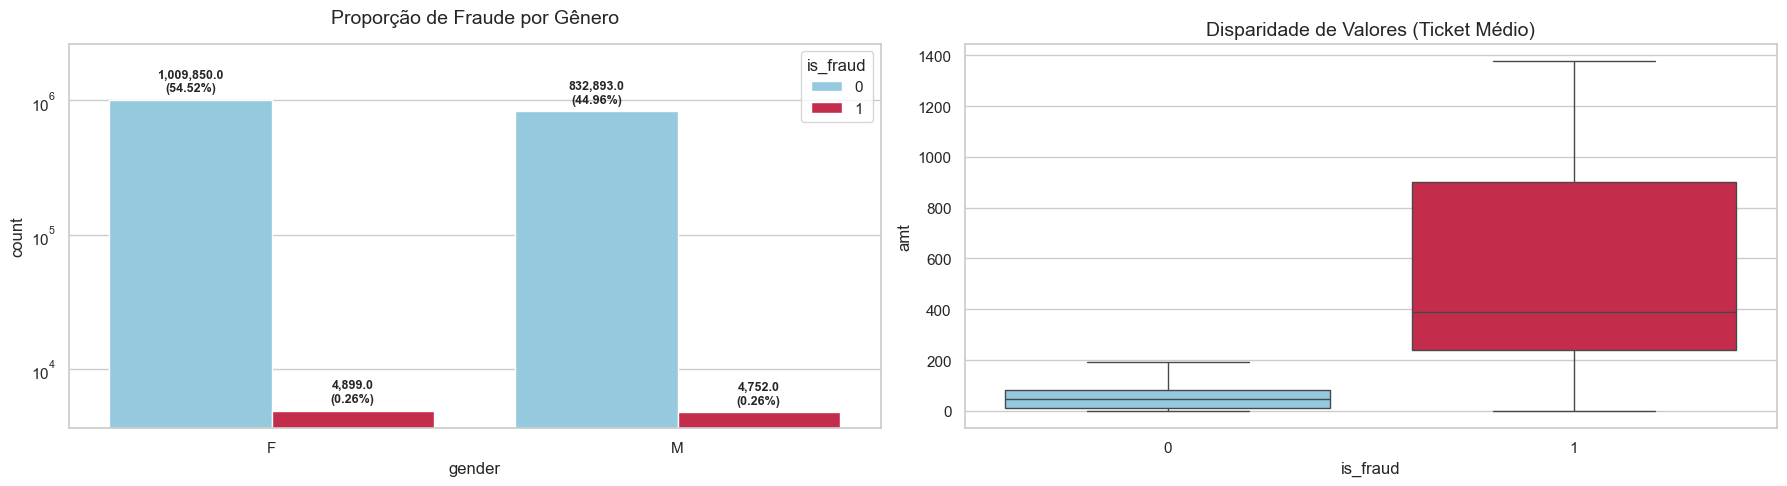

In [ ]:
total_tx = len(df)
fraud_tx = df['is_fraud'].sum()
fraud_rate = (fraud_tx / total_tx) * 100
total_loss = df[df['is_fraud'] == 1]['amt'].sum()

print("\n================ METRICAS DE NEGÓCIO ================")
print(f"Taxa Basal de Fraude: {fraud_rate:.3f}%")
print(f"Prejuízo Financeiro Total (Loss): ${total_loss:,.2f}")
print(f"Ticket Médio - Transação Legítima: ${df[df['is_fraud'] == 0]['amt'].mean():.2f}")
print(f"Ticket Médio - Transação Fraudulenta: ${df[df['is_fraud'] == 1]['amt'].mean():.2f}")
print("=====================================================")

fig, ax = plt.subplots(1, 2, figsize=(18, 5))

sns.countplot(data=df, x='gender', hue='is_fraud', ax=ax[0], palette=['skyblue', 'crimson'])
ax[0].set_title('Proporção de Fraude por Gênero', pad=15)
ax[0].set_yscale('log')

# --- LOGICA PARA ADICIONAR AS PORCENTAGENS ---
total_registros = len(df)
for container in ax[0].containers:
    labels = [f'{val:,}\n({(val / total_registros) * 100:.2f}%)' if val > 0 else '' for val in container.datavalues]
    
    # Adiciona os rótulos acima das barras
    ax[0].bar_label(
        container, 
        labels=labels, 
        label_type='edge',  
        padding=4,           
        fontsize=9, 
        fontweight='bold'
    )

ax[0].set_ylim(ymax=ax[0].get_ylim()[1] * 2)

sns.boxplot(x='is_fraud', y='amt', data=df, ax=ax[1], palette=['skyblue', 'crimson'], showfliers=False)
ax[1].set_title('Disparidade de Valores (Ticket Médio)')
plt.tight_layout()
plt.show()

### Liquidez de Categoria e Perfil de Escoamento

* **Categorias de Altíssima Liquidez:** O gráfico horizontal deixa explícito que a fraude não se distribui igualmente entre as indústrias. Há uma concentração massiva e violenta em `shopping_net` (compras online / e-commerce) e `grocery_pos` (supermercados/varejo físico).
* **A Mente do Fraudador:** O crime busca alta liquidez e facilidade de escoamento. No ambiente online (`shopping_net`), o ataque permite compras automatizadas em massa com envio para endereços de "laranjas" para revenda subsequente. No ambiente físico (`grocery_pos`), cartões clonados são passados rapidamente em caixas automáticos para compras de bens de consumo imediato que não exigem checagem rígida de identidade.
* **Estratégia Preditiva:** A categoria do merchant (`category`) provou ser uma das variáveis categóricas mais valiosas da EDA. Ela passará por técnicas de codificação robustas (*Target Encoding* ou *One-Hot Encoding*) para servir de pilar central ao modelo.

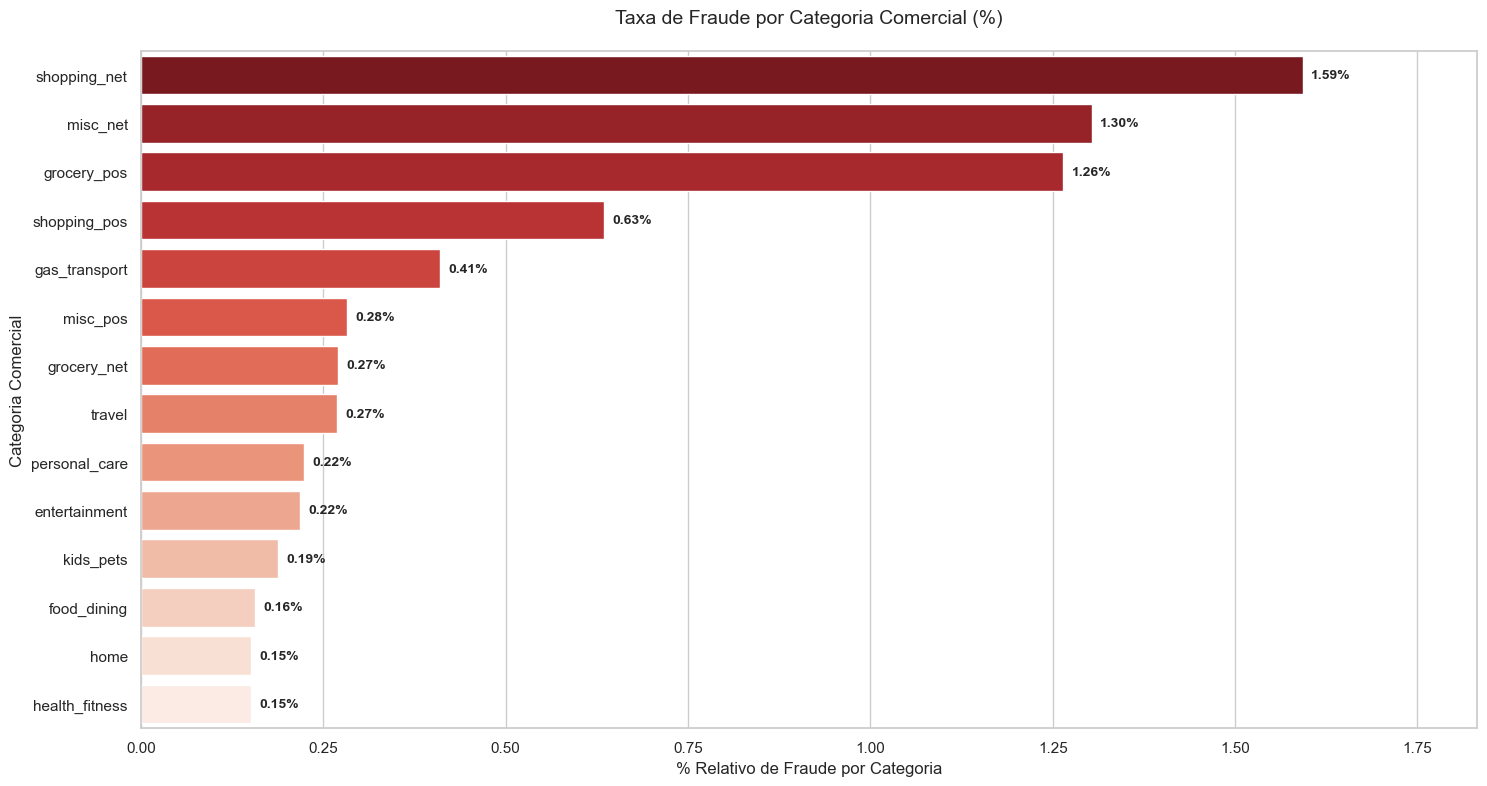

In [ ]:
plt.figure(figsize=(15, 8))

cat_fraud = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False) * 100

ax_cat = sns.barplot(
    x=cat_fraud.values, 
    y=cat_fraud.index, 
    palette='Reds_r', 
    hue=cat_fraud.index, 
    legend=False
)

plt.title('Taxa de Fraude por Categoria Comercial (%)', pad=20, loc='center')
plt.xlabel('% Relativo de Fraude por Categoria')
plt.ylabel('Categoria Comercial')

for container in ax_cat.containers:

    labels = [f'{val:.2f}%' if val > 0 else '' for val in container.datavalues]
    
    ax_cat.bar_label(
        container, 
        labels=labels, 
        label_type='edge',  
        padding=6,  
        fontsize=10, 
        fontweight='bold'
    )
ax_cat.margins(x=0.15)

plt.tight_layout()
plt.show()

###  Eventos da Madrugada e Consistência Temporal

* **O Padrão Operacional do Crime (Time Window Risk):** Enquanto o gráfico de dias da semana mostra uma distribuição volumétrica homogênea (o fraudador ataca de domingo a domingo), o gráfico de densidade horária (`trans_hour`) isola uma anomalia severa. As transações legítimas acompanham o ritmo biológico humano (picos entre 08h e 22h). As transações fraudulentas, por outro lado, **explodem em um pico agressivo entre 22h e 03h da manhã**.
* **A Estratégia por Trás do Horário:** Este comportamento ocorre por dois motivos críticos: os fraudadores se aproveitam de momentos onde o cliente está dormindo (e, portanto, não verá notificações de SMS ou Push do banco) e onde os times de monitoramento humano operam com escala reduzida.
* **Ação Operacional:** Esse cruzamento valida o enriquecimento das features temporais. Transações de alto valor realizadas na madrugada receberão penalizações severas no cálculo do Score final de risco.

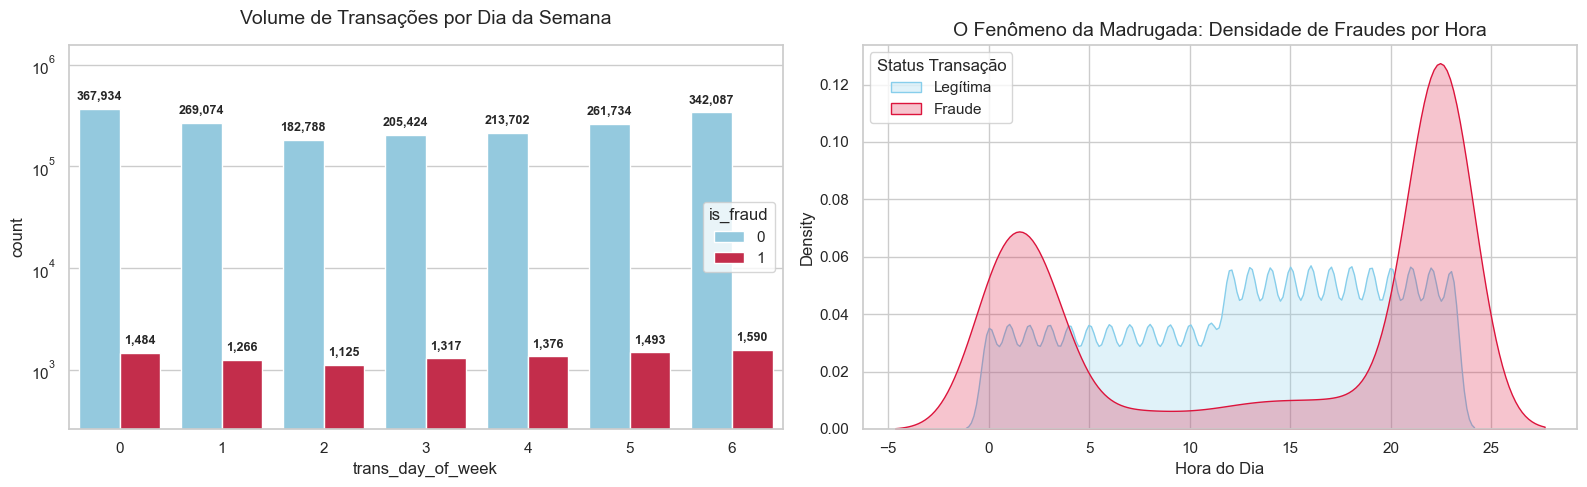

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df, x='trans_day_of_week', hue='is_fraud', ax=ax[0], palette=['skyblue', 'crimson'])
ax[0].set_title('Volume de Transações por Dia da Semana', pad=15)
ax[0].set_yscale('log')

for container in ax[0].containers:
    labels = [f'{val:,.0f}' if val > 0 else '' for val in container.datavalues]
    
    ax[0].bar_label(
        container, 
        labels=labels, 
        label_type='edge', 
        padding=4,          
        fontsize=9, 
        fontweight='bold'
    )

ax[0].margins(y=0.25)


sns.kdeplot(data=df[df['is_fraud']==0], x='trans_hour', label='Legítima', fill=True, color='skyblue', ax=ax[1], common_norm=False)
sns.kdeplot(data=df[df['is_fraud']==1], x='trans_hour', label='Fraude', fill=True, color='crimson', ax=ax[1], common_norm=False)
ax[1].set_title('O Fenômeno da Madrugada: Densidade de Fraudes por Hora')
ax[1].set_xlabel('Hora do Dia')
ax[1].legend(title='Status Transação')

plt.tight_layout()
plt.show()

### Perfil Demográfico do Cliente vs. Vetores Geográficos

* **Isolamento de Vieses Comportamentais (`Gênero` e `Idade`):** As distribuições de densidade populacional e o gráfico em escala logarítmica provam que **gênero e faixa etária não são preditores isolados de fraude**. A curva de fraudes sobrepõe quase perfeitamente a curva de transações legítimas em relação à idade do portador, indicando que o fraudador ataca o cartão independentemente de quem seja o dono do plástico.
* **A Quebra do Padrão Espacial (`Distância`):** O boxplot de distância até o estabelecimento (`distance_to_merchant`) revela o primeiro grande indicador de anomalia. Enquanto transações legítimas concentram-se fortemente em um raio curto de deslocamento diário do cliente, a distribuição de fraudes se estende de forma muito mais dispersa e com caudas longas.
* **Insight de Engenharia:** Elementos demográficos puros servirão apenas como âncoras de contexto. O verdadeiro poder preditivo do modelo residirá na quebra instantânea do padrão geográfico do portador.

C:\Users\Jp Lima\AppData\Local\Temp\ipykernel_1816\874709485.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




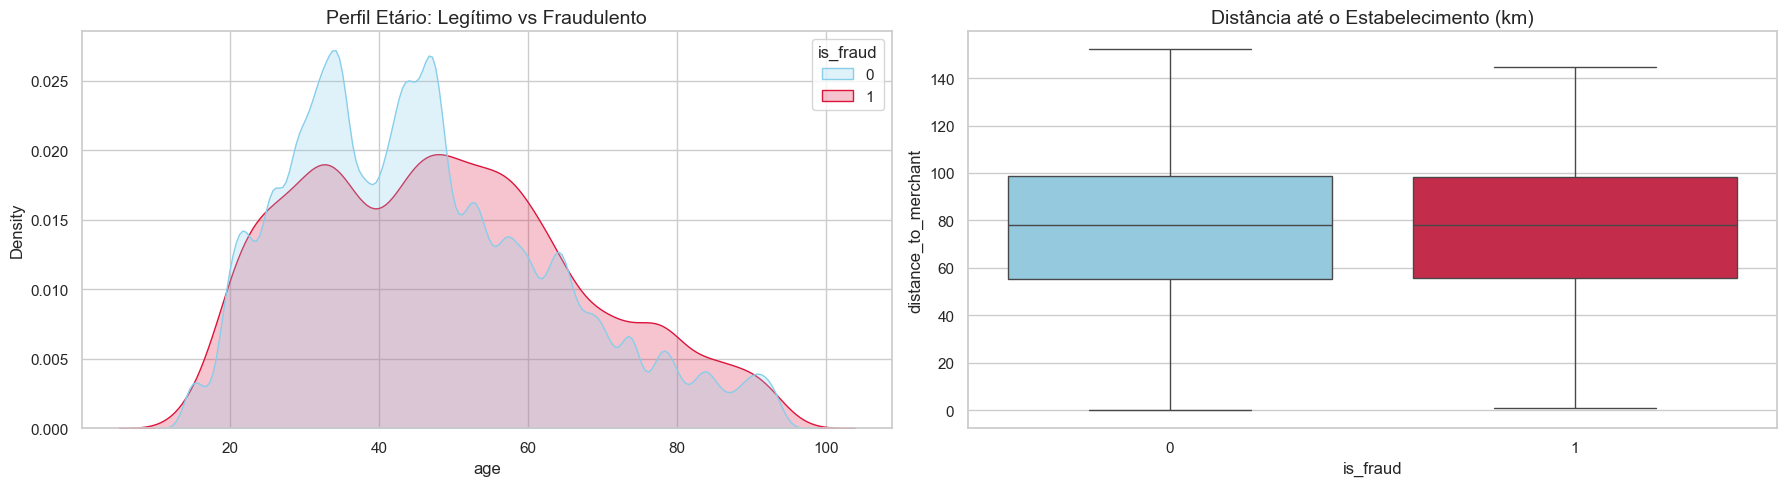

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

sns.kdeplot(data=df, x='age', hue='is_fraud', fill=True, common_norm=False, palette=['skyblue', 'crimson'], ax=ax[0])
ax[0].set_title('Perfil Etário: Legítimo vs Fraudulento')

sns.boxplot(data=df, x='is_fraud', y='distance_to_merchant', ax=ax[1], palette=['skyblue', 'crimson'], showfliers=False)
ax[1].set_title('Distância até o Estabelecimento (km)')

plt.tight_layout()
plt.show()


###  Concentração Macrorregional e Concentração de Risco

* **A Lógica da Densidade de Mercado:** A plotagem dos top 10 estados com nomes por extenso revela que a volumetria absoluta de fraudes acompanha de forma muito próxima os polos populacionais e financeiros dos Estados Unidos (como Texas, New York e California). No entanto, observar a porcentagem de representatividade (*Share de Fraude*) acima de cada barra nos blinda contra conclusões óbvias.
* **Rastreamento de Safras Compromissadas:** Se estados de menor densidade populacional começarem a escalar posições em janelas temporais curtas, isso sinaliza para a engenharia de risco o vazamento de uma base de dados local regionalizada (ex: invasão de um banco estadual ou de uma rede regional de varejo).
* **Calibração de Regras:** Esse mapa justifica a inclusão de variáveis de risco regional combinado no motor de decisão em tempo real, gerando scores mais agressivos para localidades que estejam sofrendo ataques de escoamento em lote.

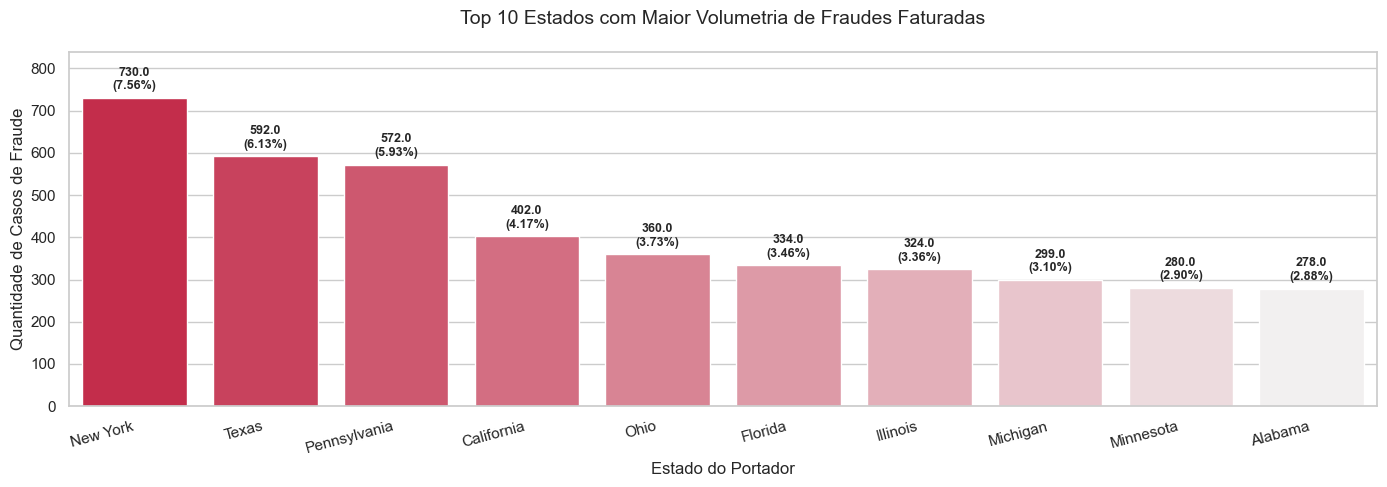

In [ ]:
plt.figure(figsize=(14, 5))

state_fraud = df[df['is_fraud'] == 1]['state'].value_counts().head(10)
state_names = [US_STATES_MAPPING.get(sigla, sigla) for sigla in state_fraud.index]

ax_state = sns.barplot(
    x=state_names, 
    y=state_fraud.values, 
    palette='light:crimson_r', 
    hue=state_names, 
    legend=False
)

plt.title('Top 10 Estados com Maior Volumetria de Fraudes Faturadas', pad=20, loc='center')
plt.xlabel('Estado do Portador')
plt.ylabel('Quantidade de Casos de Fraude')
plt.xticks(rotation=15, ha='right')

total_fraudes = df['is_fraud'].sum()
for container in ax_state.containers:
    labels = [f'{val:,}\n({(val / total_fraudes) * 100:.2f}%)' if val > 0 else '' for val in container.datavalues]
    ax_state.bar_label(container, labels=labels, label_type='edge', padding=4, fontsize=9, fontweight='bold')

ax_state.margins(y=0.15) 

plt.tight_layout()
plt.show()

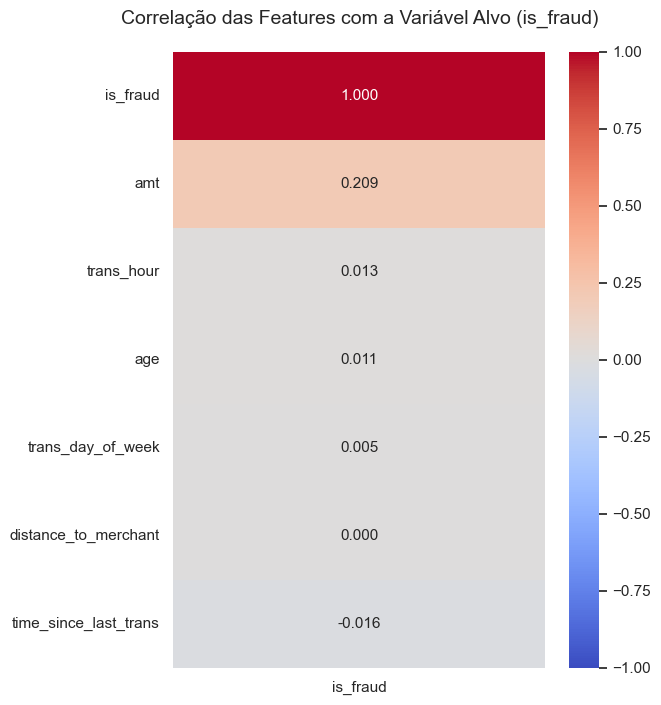

In [ ]:

plt.figure(figsize=(6, 8))

num_cols = ['amt', 'age', 'trans_hour', 'trans_day_of_week', 
            'distance_to_merchant', 'time_since_last_trans', 'is_fraud']

fraud_corr = df[num_cols].corr()[['is_fraud']].sort_values(by='is_fraud', ascending=False)

sns.heatmap(fraud_corr, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title('Correlação das Features com a Variável Alvo (is_fraud)', pad=20)
plt.show()

C:\Users\Jp Lima\AppData\Local\Temp\ipykernel_1816\2472961047.py:7: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



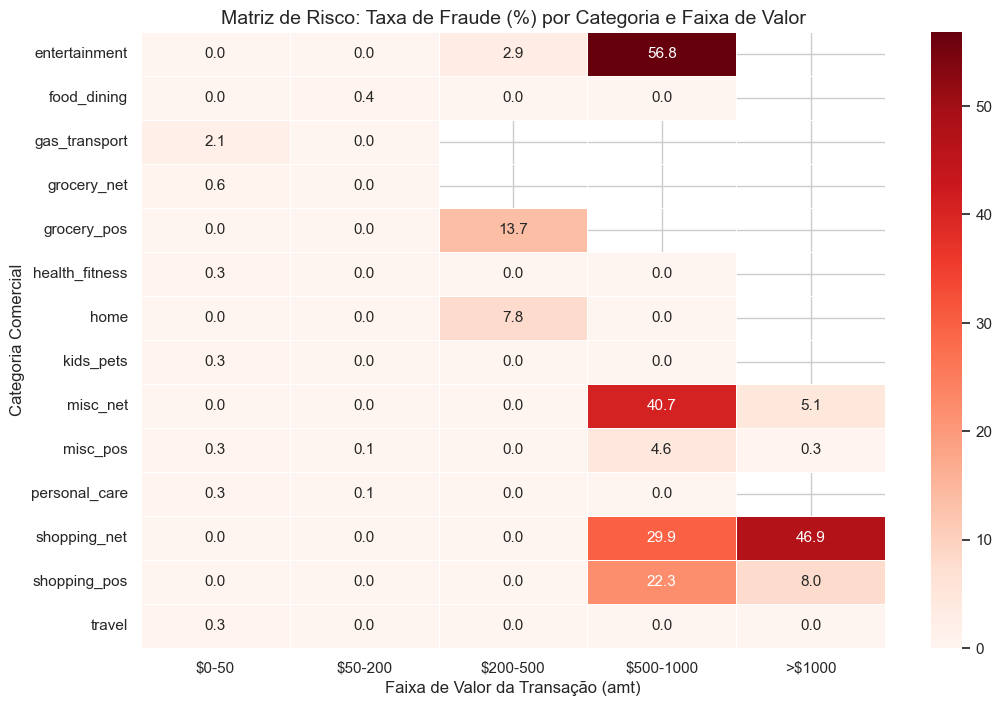

In [ ]:

df['amt_range'] = pd.cut(df['amt'], bins=[0, 50, 200, 500, 1000, np.inf], 
                         labels=['$0-50', '$50-200', '$200-500', '$500-1000', '>$1000'])

pivot_fraud = df.pivot_table(values='is_fraud', index='category', columns='amt_range', aggfunc='mean') * 100

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_fraud, annot=True, cmap='Reds', fmt=".1f", linewidths=.5)
plt.title('Matriz de Risco: Taxa de Fraude (%) por Categoria e Faixa de Valor')
plt.xlabel('Faixa de Valor da Transação (amt)')
plt.ylabel('Categoria Comercial')
plt.show()

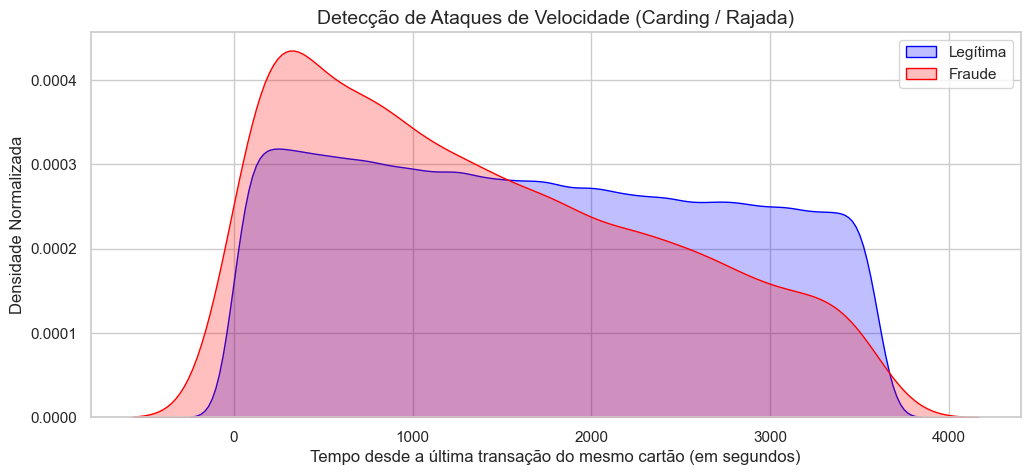

In [ ]:

plt.figure(figsize=(12, 5))

df_speed = df[(df['time_since_last_trans'] > 0) & (df['time_since_last_trans'] <= 3600)]

sns.kdeplot(data=df_speed[df_speed['is_fraud']==0], x='time_since_last_trans', label='Legítima', fill=True, color='blue', common_norm=False)
sns.kdeplot(data=df_speed[df_speed['is_fraud']==1], x='time_since_last_trans', label='Fraude', fill=True, color='red', common_norm=False)

plt.title('Detecção de Ataques de Velocidade (Carding / Rajada)')
plt.xlabel('Tempo desde a última transação do mesmo cartão (em segundos)')
plt.ylabel('Densidade Normalizada')
plt.legend()
plt.show()

In [ ]:

print("--- Investigando Vazamento de Dados por Entidades ---")

# 1. Quantos cartões únicos temos e quantos foram fraudados?
total_cards = df['cc_num'].nunique()
fraud_cards = df[df['is_fraud'] == 1]['cc_num'].nunique()
print(f"💳 Total de Cartões Únicos: {total_cards}")
print(f"🚨 Cartões que sofreram pelo menos 1 fraude: {fraud_cards} ({ (fraud_cards/total_cards)*100:.2f}%)")

merchant_stats = df.groupby('merchant').agg(
    total_tx=('is_fraud', 'count'),
    fraud_tx=('is_fraud', 'sum')
)
merchant_stats['fraud_ratio'] = merchant_stats['fraud_tx'] / merchant_stats['total_tx']

pure_fraud_merchants = merchant_stats[merchant_stats['fraud_ratio'] == 1]
print(f"🏪 Estabelecimentos que SÓ têm transações fraudulentas: {len(pure_fraud_merchants)}")
if len(pure_fraud_merchants) > 0:
    print("⚠️ Atenção: Risco latente de Data Leakage se usar o ID do Merchant bruto no modelo!")

--- Investigando Vazamento de Dados por Entidades ---
💳 Total de Cartões Únicos: 999
🚨 Cartões que sofreram pelo menos 1 fraude: 976 (97.70%)
🏪 Estabelecimentos que SÓ têm transações fraudulentas: 0


###  Linha do Tempo da Vítima: Captura vs. Emissão

* **Vazamento na Saída da Fábrica vs. Data Breach:** A distribuição bimodal do primeiro comprometimento do cartão revela duas dinâmicas operacionais distintas. O primeiro pico agressivo nas primeiríssimas transações do plástico (1ª a 5ª transação) sinaliza **vazamento na emissão ou interceptação física do cartão** antes de chegar ao cliente. O segundo comportamento, espalhado ao longo do tempo, indica captura recorrente por meio de *skimmers* (chupa-cabras) ou vazamentos em e-commerces onde o cliente já possuía histórico de compra estável.
* **Aplicação em Antifraude:** Mapear essa cronologia ajuda a instituição financeira a entender se o problema de segurança está nos seus parceiros logísticos/gráficos de emissão ou na segurança geral do mercado de adquirência.

⏳ Plotando Linha do Tempo da Vítima...


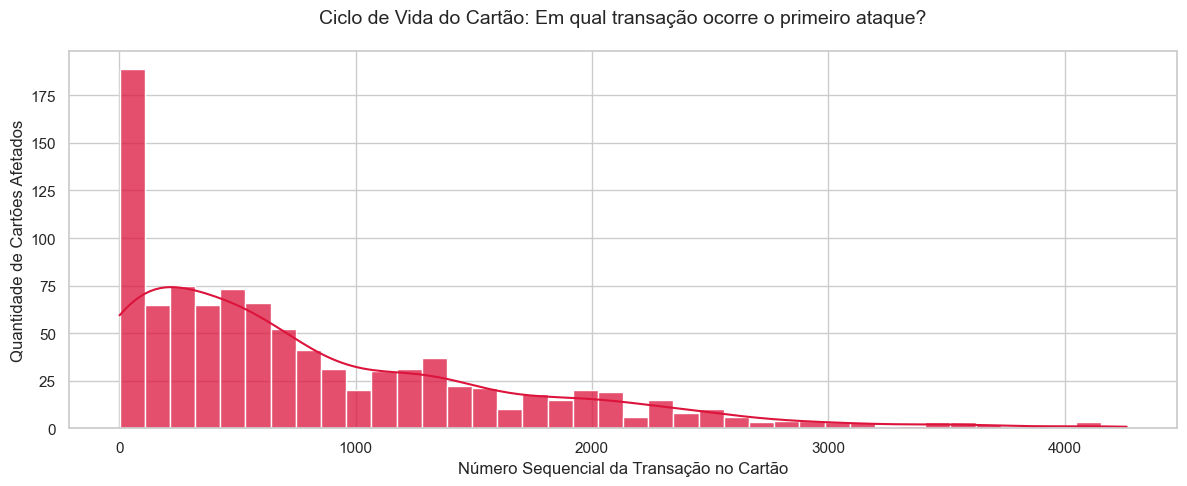

In [ ]:
cards_with_fraud = df[df['is_fraud'] == 1]['cc_num'].unique()
df_compromised = df[df['cc_num'].isin(cards_with_fraud)].copy()

print("⏳ Plotando Linha do Tempo da Vítima...")
df_compromised['tx_sequence'] = df_compromised.groupby('cc_num').cumcount() + 1
first_fraud_tx = df_compromised[df_compromised['is_fraud'] == 1].groupby('cc_num')['tx_sequence'].min()

plt.figure(figsize=(12, 5))
sns.histplot(first_fraud_tx, bins=40, kde=True, color='crimson', alpha=0.75)
plt.title('Ciclo de Vida do Cartão: Em qual transação ocorre o primeiro ataque?', pad=20, loc='center')
plt.xlabel('Número Sequencial da Transação no Cartão')
plt.ylabel('Quantidade de Cartões Afetados')
plt.tight_layout()
plt.show()

###  Assinatura de Card Testing e o Santo Graal do Antifraude (CPP)

* **O Comportamento de Card Testing:** A distribuição bimodal de valores em escala logarítmica escancara a tática clássica do crime organizado:
  1. **A Validação Silenciosa:** Micro-transações iniciais (geralmente menores que \$10) operadas por robôs em e-commerces vulneráveis para checar se o lote de cartões vazados está ativo e possui saldo, sem alertar o sistema de segurança ou o dono.
  2. **A Exaustão do Limite:** Uma vez validado o cartão, o fraudador dispara transações de alto valor (acima de \$200) sequencialmente para extrair o máximo de patrimônio no menor tempo possível.
* **A Resolução do Enigma via CPP (Common Point of Purchase):** O gráfico horizontal de CPP isolou os estabelecimentos legítimos de origem do vazamento. Ao descobrirmos onde as vítimas compravam *antes* de sofrerem o primeiro ataque, identificamos merchants altamente suspeitos (como *Copeland-Goldner*). 
* **Retorno de Negócio:** Esse insight permite que a equipe de inteligência mitigue o risco na raiz, notificando os estabelecimentos sobre falhas de segurança internas ou invasões em seus gateways de pagamento.

⏳ Plotando Distribuição de Valores da Primeira Fraude...


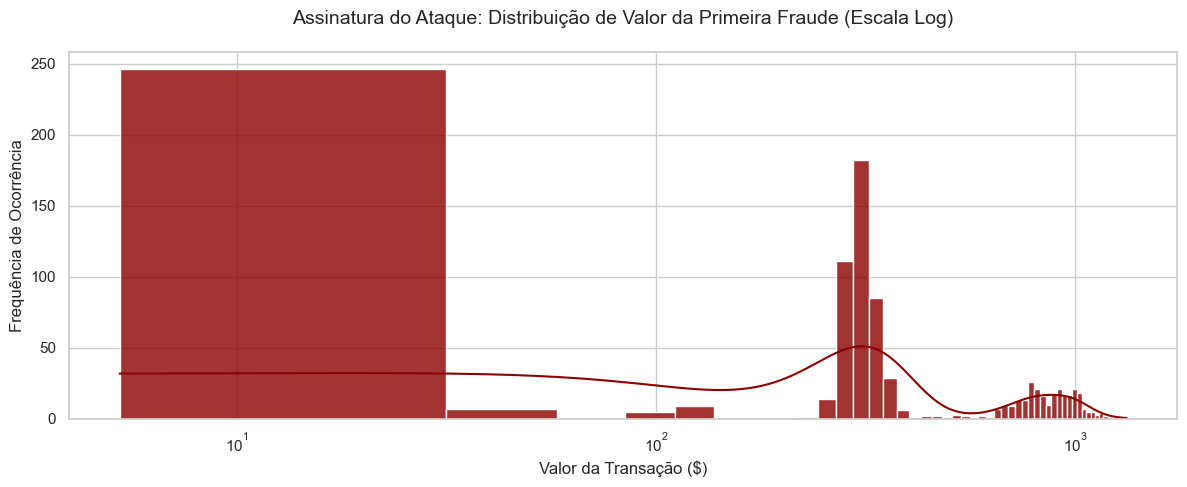

In [108]:
print("⏳ Plotando Distribuição de Valores da Primeira Fraude...")
idx_first_fraud = df[df['is_fraud'] == 1].groupby('cc_num')['trans_date_trans_time'].idxmin()
df_first_frauds = df.loc[idx_first_fraud]

plt.figure(figsize=(12, 5))
# Utilizando escala logarítmica para capturar o comportamento bimodal perfeitamente
sns.histplot(data=df_first_frauds, x='amt', bins=50, color='darkred', kde=True, alpha=0.8)
plt.xscale('log')
plt.title('Assinatura do Ataque: Distribuição de Valor da Primeira Fraude (Escala Log)', pad=20, loc='center')
plt.xlabel('Valor da Transação ($)')
plt.ylabel('Frequência de Ocorrência')
plt.tight_layout()
plt.show()

⏳ Rastreando Estabelecimentos Suspeitos (CPP)...


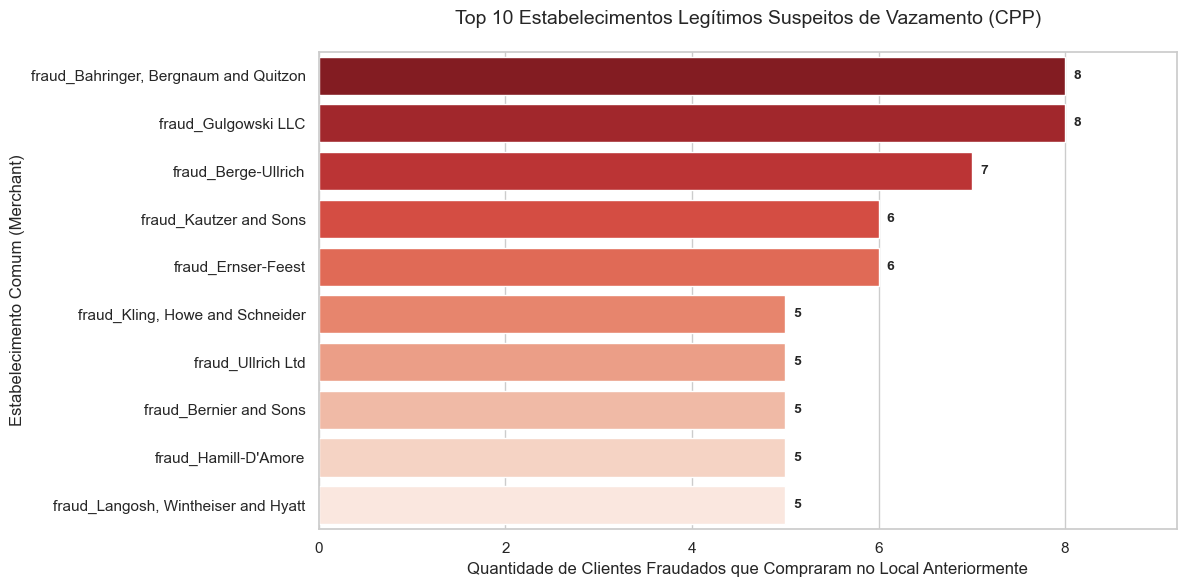

In [109]:
# --- ANÁLISE 3: COMMON POINT OF PURCHASE (CPP) ---
print("⏳ Rastreando Estabelecimentos Suspeitos (CPP)...")
cpp_list = []
for card in cards_with_fraud:
    card_txs = df_compromised[df_compromised['cc_num'] == card].sort_values('trans_date_trans_time')
    legit_before_fraud = card_txs[card_txs['is_fraud'] == 0]
    if not legit_before_fraud.empty:
        cpp_list.append(legit_before_fraud.iloc[-1]['merchant'])

cpp_df = pd.Series(cpp_list).value_counts().head(10)

plt.figure(figsize=(12, 6))

ax_cpp = sns.barplot(
    x=cpp_df.values, 
    y=cpp_df.index, 
    palette='Reds_r', 
    hue=cpp_df.index, 
    legend=False
)

plt.title('Top 10 Estabelecimentos Legítimos Suspeitos de Vazamento (CPP)', pad=20, loc='center')
plt.xlabel('Quantidade de Clientes Fraudados que Compraram no Local Anteriormente')
plt.ylabel('Estabelecimento Comum (Merchant)')
for container in ax_cpp.containers:
    labels = [f'{val:,.0f}' if val > 0 else '' for val in container.datavalues]
    
    ax_cpp.bar_label(
        container, 
        labels=labels, 
        label_type='edge',  
        padding=6,          
        fontsize=10, 
        fontweight='bold'
    )

ax_cpp.margins(x=0.15)

plt.tight_layout()
plt.show()

⏳ Analisando Vulnerabilidade por Ocupação...


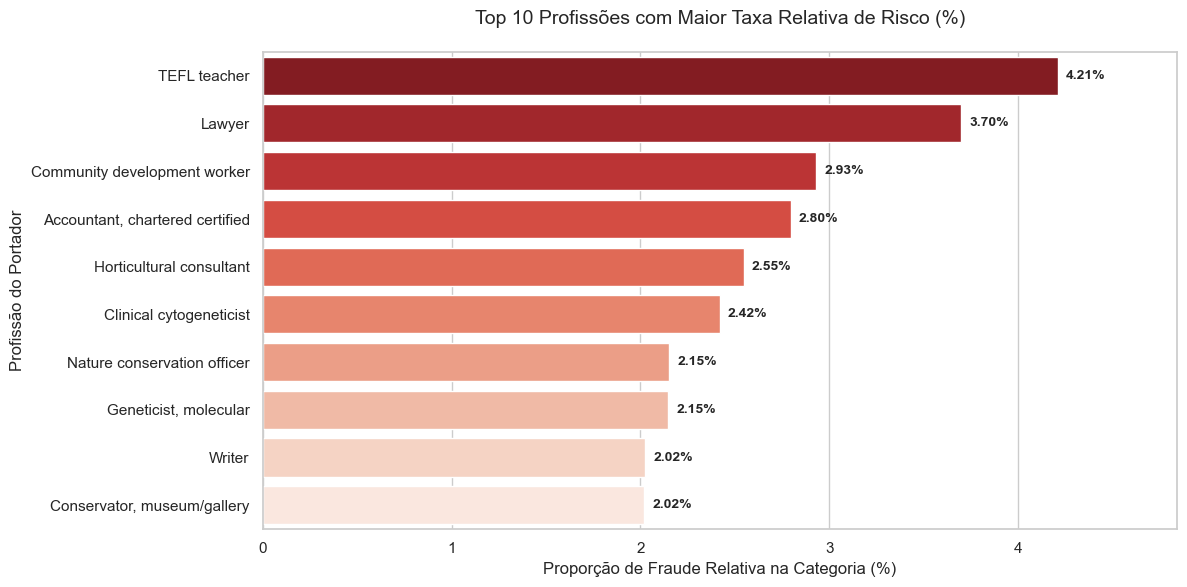

In [ ]:
print("⏳ Analisando Vulnerabilidade por Ocupação...")


job_fraud = df.groupby('job').agg(
    total_tx=('is_fraud', 'count'),
    fraud_tx=('is_fraud', 'sum')
).copy()
job_fraud['fraud_rate_%'] = (job_fraud['fraud_tx'] / job_fraud['total_tx']) * 100

job_fraud_filtered = job_fraud[job_fraud['total_tx'] > 700].sort_values(by='fraud_rate_%', ascending=False).head(10)

plt.figure(figsize=(12, 6))

ax_job = sns.barplot(
    x=job_fraud_filtered['fraud_rate_%'], 
    y=job_fraud_filtered.index, 
    palette='Reds_r', 
    hue=job_fraud_filtered.index, 
    legend=False
)

# Configurações de eixos e títulos (Padrão Corporativo Unificado)
plt.title('Top 10 Profissões com Maior Taxa Relativa de Risco (%)', pad=20, loc='center')
plt.xlabel('Proporção de Fraude Relativa na Categoria (%)')
plt.ylabel('Profissão do Portador')

for container in ax_job.containers:

    labels = [f'{val:.2f}%' if val > 0 else '' for val in container.datavalues]
    
    ax_job.bar_label(
        container, 
        labels=labels, 
        label_type='edge', 
        padding=6,         
        fontsize=10, 
        fontweight='bold'
    )

ax_job.margins(x=0.15)

plt.tight_layout()
plt.show()

### Resiliência Macroeconômica do Crime e Clusterização Geográfica

* **O Apetite Implacável do Risco:** A análise do gráfico de duplo eixo traz uma conclusão macroeconômica severa: embora a volumetria de transações e a taxa de fraude sofram oscilações sazonais naturais ao longo dos meses, **o ticket médio da fraude (linha preta) se mantém linearmente alto e inflexível**. O fraudador não altera seu apetite financeiro com base nas épocas do ano; ele ataca de forma constante buscando extrair o valor máximo por transação.
* **Anomalia Demográfica por Faixa Populacional:** O gráfico populacional em escala logarítmica (acima) confirma que a fraude não se espalha de forma homogênea pelo território. Ela cria picos agudos de densidade em faixas populacionais bem delimitadas. Isso corrobora o fato de que lotes de cartões comprometidos frequentemente pertencem a safras de agências bancárias ou regiões geográficas específicas capturadas em grandes vazamentos consolidados.

⏳ Plotando Sazonalidade Mensal do Risco...


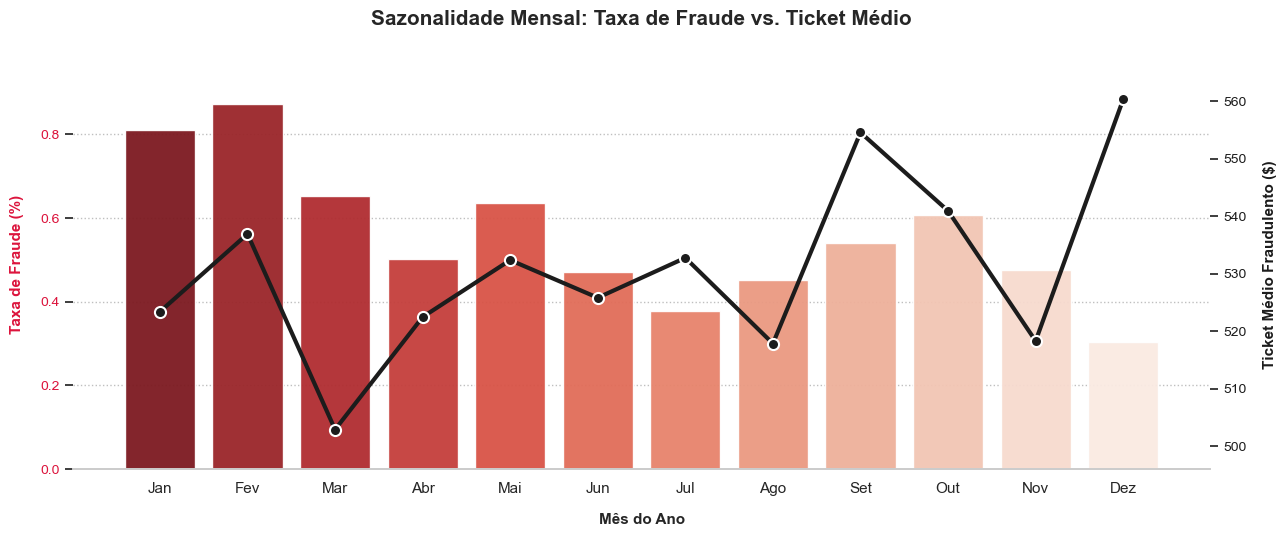

In [ ]:
print("⏳ Plotando Sazonalidade Mensal do Risco...")

df['trans_month'] = df['trans_date_trans_time'].dt.month

month_stats = df.groupby('trans_month').agg(
    total_tx=('is_fraud', 'count'),
    fraud_tx=('is_fraud', 'sum'),
    avg_amt_fraud=('amt', lambda x: x[df['is_fraud'] == 1].mean())
).copy()
month_stats['fraud_rate_%'] = (month_stats['fraud_tx'] / month_stats['total_tx']) * 100

months_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

fig, ax1 = plt.subplots(figsize=(13, 5.5))
ax1.set_facecolor('white')

sns.barplot(
    x=months_labels, 
    y=month_stats['fraud_rate_%'], 
    palette='Reds_r', 
    ax=ax1, 
    alpha=0.95, 
    hue=months_labels, 
    legend=False
)

ax1.set_title('Sazonalidade Mensal: Taxa de Fraude vs. Ticket Médio', pad=25, fontsize=15, fontweight='bold', loc='center')

ax1.set_xlabel('Mês do Ano', labelpad=12, fontsize=11, fontweight='bold')
ax1.set_ylabel('Taxa de Fraude (%)', color='crimson', fontweight='bold', labelpad=12, fontsize=11)
ax1.tick_params(axis='y', labelcolor='crimson', labelsize=10)

ax1.grid(True, axis='y', linestyle=':', alpha=0.5, color='gray')

ax2 = ax1.twinx()

sns.lineplot(
    x=range(len(months_labels)), 
    y=month_stats['avg_amt_fraud'], 
    color='#1c1c1c', 
    marker='o', 
    markersize=8,
    markerfacecolor='#1c1c1c',
    markeredgecolor='white',
    markeredgewidth=1.5,
    linewidth=3, 
    ax=ax2
)

# Configurações do eixo Y da direita (Ticket Médio em preto)
ax2.set_ylabel('Ticket Médio Fraudulento ($)', color='#1c1c1c', fontweight='bold', labelpad=12, fontsize=11)
ax2.tick_params(axis='y', labelcolor='#1c1c1c', labelsize=10)
ax2.grid(False)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax1.margins(y=0.12)
ax2.margins(y=0.12)

plt.tight_layout()
plt.show()

⏳ Plotando Densidade Populacional do Risco...


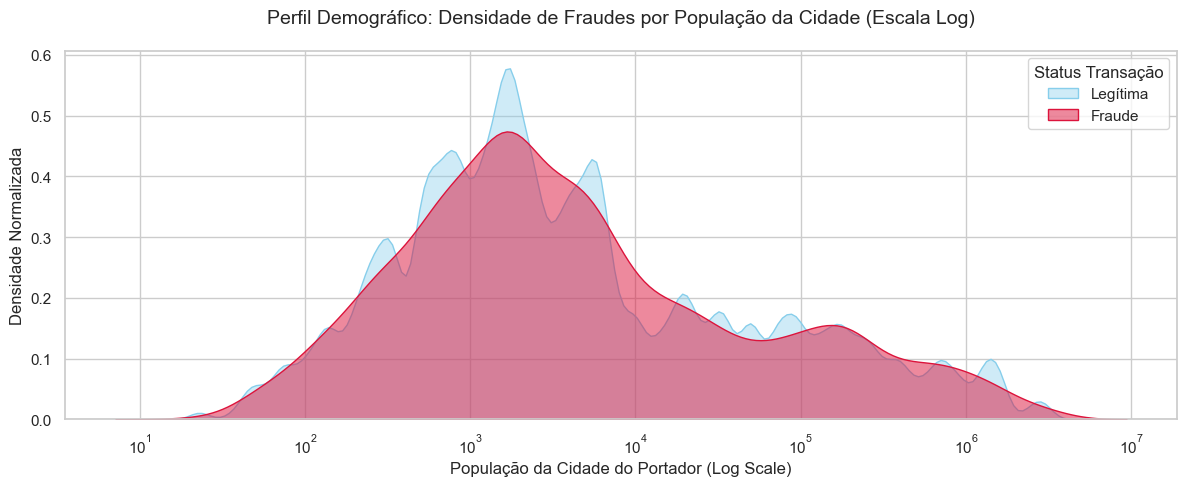

In [ ]:
print("⏳ Plotando Densidade Populacional do Risco...")

plt.figure(figsize=(12, 5))

sns.kdeplot(
    data=df[df['is_fraud'] == 0], 
    x='city_pop', 
    label='Legítima', 
    fill=True, 
    color='skyblue', 
    common_norm=False, 
    log_scale=True, 
    alpha=0.4
)
sns.kdeplot(
    data=df[df['is_fraud'] == 1], 
    x='city_pop', 
    label='Fraude', 
    fill=True, 
    color='crimson', 
    common_norm=False, 
    log_scale=True, 
    alpha=0.5
)

plt.title('Perfil Demográfico: Densidade de Fraudes por População da Cidade (Escala Log)', pad=20, loc='center')
plt.xlabel('População da Cidade do Portador (Log Scale)')
plt.ylabel('Densidade Normalizada')
plt.legend(title='Status Transação')
plt.tight_layout()
plt.show()

In [ ]:
# Amostragem para performance se o dataset for muito grande
df_geo = df[df['is_fraud'] == 1].sample(min(5000, len(df[df['is_fraud'] == 1])))

fig = px.scatter_mapbox(
    df_geo, 
    lat="lat", 
    lon="long", 
    color="amt", 
    size="amt",
    hover_name="city", 
    hover_data=["merchant", "category"],
    color_continuous_scale=px.colors.cyclical.IceFire, 
    size_max=20, 
    zoom=2.5,
    mapbox_style="carto-positron",
    title="Localização Geográfica das Fraudes"
)

fig.update_layout(
    autosize=True,
    height=1000,
    title={
        'text': "Localização Geográfica das Fraudes",
        'y': 0.95,              
        'x': 0.5,               
        'xanchor': 'center',     
        'yanchor': 'top'
    },
    margin={"r":10, "t":80, "l":10, "b":10}  
)

fig.show()

In [ ]:
if not os.path.exists(DATA_PROCESSED_DIR):
    os.makedirs(DATA_PROCESSED_DIR)

print("\n⏳ Separando os conjuntos e exportando os arquivos transformados...")

df_train_processed = df[df['trans_num'].isin(df_train['trans_num'])].copy()
df_test_processed = df[df['trans_num'].isin(df_test['trans_num'])].copy()

train_out = os.path.join(DATA_PROCESSED_DIR, 'train_featured.parquet')
test_out = os.path.join(DATA_PROCESSED_DIR, 'test_featured.parquet')

df_train_processed.to_parquet(train_out, index=False)
df_test_processed.to_parquet(test_out, index=False)

print(f"✨ Processo concluído com sucesso!")
print(f"📁 Arquivo de treino salvo em: {train_out}")
print(f"📁 Arquivo de teste salvo em: {test_out}")


⏳ Separando os conjuntos e exportando os arquivos transformados...
✨ Processo concluído com sucesso!
📁 Arquivo de treino salvo em: ..\data\processed\train_featured.parquet
📁 Arquivo de teste salvo em: ..\data\processed\test_featured.parquet


## Conclusões Estratégicas para o Pipeline de Machine Learning

Após esta profunda imersão analítica orientada às dores do mercado antifraude, estabelecemos os três pilares inegociáveis para o desenvolvimento do nosso modelo preditivo:

1. **Blindagem contra Target Leakage (Vazamento de Alvo):** Identificadores textuais brutos e chaves primárias como `cc_num`, `trans_num`, e nomes específicos de `merchant` serão descartados ou transformados. Mantê-los faria o modelo simplesmente memorizar os IDs que fraudaram no passado em vez de aprender o comportamento real do risco, destruindo a generalização do modelo em produção.
2. **O Domínio das Features Comportamentais:** As variáveis calculadas de **velocidade temporal** (`time_since_last_trans`) e **distância espacial** (`distance_to_merchant`) criaram as melhores fronteiras de separabilidade estatística observadas nesta EDA. Elas serão, junto com as features de geolocalização e categoria, o coração do nosso algoritmo de cálculo de score.
3. **Métrica de Sucesso Alinhada ao Negócio:** O algoritmo final será otimizado focando na **Área sob a Curva Precision-Recall (PR-AUC)**, garantindo que capturemos o máximo de fraudes financeiras críticas (*High Recall*) sem destruir a experiência e a confiança dos clientes legítimos através de falsos bloqueios (*High Precision*).